# Event Track Extraction Demo

This notebook loads an existing tracked `VideoAsset`, builds the visual identity layer, computes mask-based visual events, and renders motion-track visualizations. It is local-only: no server, SAM3, or LLM calls are made.

In [1]:
import json
from collections import Counter
from pathlib import Path

from v2a_inspect.models import VideoAsset
from v2a_inspect.preprocessing import build_visual_identity_layer, compute_visual_events
from v2a_inspect.visualization import (
    display_image,
    display_video,
    render_motion_tracks_image,
    render_motion_tracks_video,
    render_visual_timeline,
)

## Config

The input defaults to the artifact produced by `agent_seed_tracking.ipynb`. Outputs are written to a separate folder so the tracking artifact is not mutated.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_ASSET_PATH = PROJECT_ROOT / "demo" / "outputs" / "agent_seed_tracking" / "video_asset.json"
OUTPUT_DIR = PROJECT_ROOT / "demo" / "outputs" / "event_track_extraction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_EVENT_TYPES = {"motion", "fast_motion"}
SELECTED_SCENE_INDEXES = None
RENDER_VIDEO = True
SAVE_EVENT_ASSET = True

INPUT_ASSET_PATH

PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/video_asset.json')

## Load Tracked Asset

The saved demo JSON can contain Pydantic computed fields. The helper below strips those fields before validation.

In [3]:
COMPUTED_VIDEO_KEYS = {
    "width",
    "height",
    "fps",
    "sam3_tracking_width",
    "sam3_tracking_height",
    "sam3_tracking_fps",
    "duration_sec",
}
COMPUTED_SCENE_KEYS = {"frame_count"}
COMPUTED_TRACK_KEYS = {"start_frame_index", "end_frame_index", "frame_count"}


def load_saved_video_asset(asset_path: Path) -> VideoAsset:
    payload = json.loads(asset_path.read_text(encoding="utf-8"))
    for key in COMPUTED_VIDEO_KEYS:
        payload.pop(key, None)
    for scene in payload["initial_scenes"]:
        for key in COMPUTED_SCENE_KEYS:
            scene.pop(key, None)
        for track in scene["scene_tracks"]:
            for key in COMPUTED_TRACK_KEYS:
                track.pop(key, None)
    return VideoAsset.model_validate(payload)


video_asset = load_saved_video_asset(INPUT_ASSET_PATH)
{
    "source_path": str(video_asset.source_path),
    "scene_count": len(video_asset.initial_scenes),
    "scene_track_count": sum(len(scene.scene_tracks) for scene in video_asset.initial_scenes),
}

{'source_path': '/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/work/13.prepared.mp4',
 'scene_count': 11,
 'scene_track_count': 20}

## Compute Visual Events

This rebuilds the identity layer from scene tracks and computes visual events from masks. It does not write back to the input artifact.

In [4]:
video_asset = build_visual_identity_layer(video_asset)
video_asset = compute_visual_events(video_asset)
visual_identity_layer = video_asset.visual_identity_layer
assert visual_identity_layer is not None

event_counts = Counter(event.event_type for event in visual_identity_layer.visual_events)
{
    "visual_object_count": len(visual_identity_layer.visual_objects),
    "visual_event_count": len(visual_identity_layer.visual_events),
    "event_counts": dict(sorted(event_counts.items())),
}

{'visual_object_count': 20,
 'visual_event_count': 70,
 'event_counts': {'appearance': 20,
  'contact': 2,
  'disappearance': 20,
  'fast_motion': 4,
  'motion': 10,
  'scale_change': 8,
  'stationary': 6}}

## Event Table

The rows below are compact and notebook-friendly. Contact events include `related_labels`.

In [5]:
label_by_object_id = {
    visual_object.visual_object_id: visual_object.label or "object"
    for visual_object in visual_identity_layer.visual_objects
}
scene_by_track_id = {}
for scene_index, scene in enumerate(video_asset.initial_scenes):
    for track in scene.scene_tracks:
        scene_by_track_id[track.scene_track_id] = scene_index

scene_by_object_id = {}
for visual_object in visual_identity_layer.visual_objects:
    scene_index = None
    for presence in visual_object.presences:
        if presence.scene_track_id in scene_by_track_id:
            scene_index = scene_by_track_id[presence.scene_track_id]
            break
    scene_by_object_id[visual_object.visual_object_id] = scene_index

event_rows = []
for event in sorted(
    visual_identity_layer.visual_events,
    key=lambda item: (item.start_frame_index, item.event_type, str(item.visual_object_id)),
):
    related_labels = [label_by_object_id[object_id] for object_id in event.related_visual_object_ids]
    event_rows.append(
        {
            "scene_index": scene_by_object_id[event.visual_object_id],
            "label": label_by_object_id[event.visual_object_id],
            "event_type": event.event_type,
            "start_frame_index": event.start_frame_index,
            "end_frame_index": event.end_frame_index,
            "confidence": round(event.confidence, 3),
            "description": event.description,
            "related_labels": related_labels,
        }
    )

event_rows[:40]

[{'scene_index': 0,
  'label': 'helmet',
  'event_type': 'appearance',
  'start_frame_index': 0,
  'end_frame_index': 1,
  'confidence': 0.824,
  'description': 'appears',
  'related_labels': []},
 {'scene_index': 0,
  'label': 'helmet',
  'event_type': 'motion',
  'start_frame_index': 0,
  'end_frame_index': 60,
  'confidence': 0.824,
  'description': 'moves left',
  'related_labels': []},
 {'scene_index': 0,
  'label': 'helmet',
  'event_type': 'disappearance',
  'start_frame_index': 59,
  'end_frame_index': 60,
  'confidence': 0.824,
  'description': 'disappears',
  'related_labels': []},
 {'scene_index': 1,
  'label': 'man',
  'event_type': 'appearance',
  'start_frame_index': 61,
  'end_frame_index': 62,
  'confidence': 0.867,
  'description': 'appears',
  'related_labels': []},
 {'scene_index': 1,
  'label': 'boy',
  'event_type': 'appearance',
  'start_frame_index': 61,
  'end_frame_index': 62,
  'confidence': 0.714,
  'description': 'appears',
  'related_labels': []},
 {'scene_

## Visual Object And Event Timeline

The full timeline shows object presences as long bars and visual events as colored overlays. A filtered timeline focuses on motion/contact events.

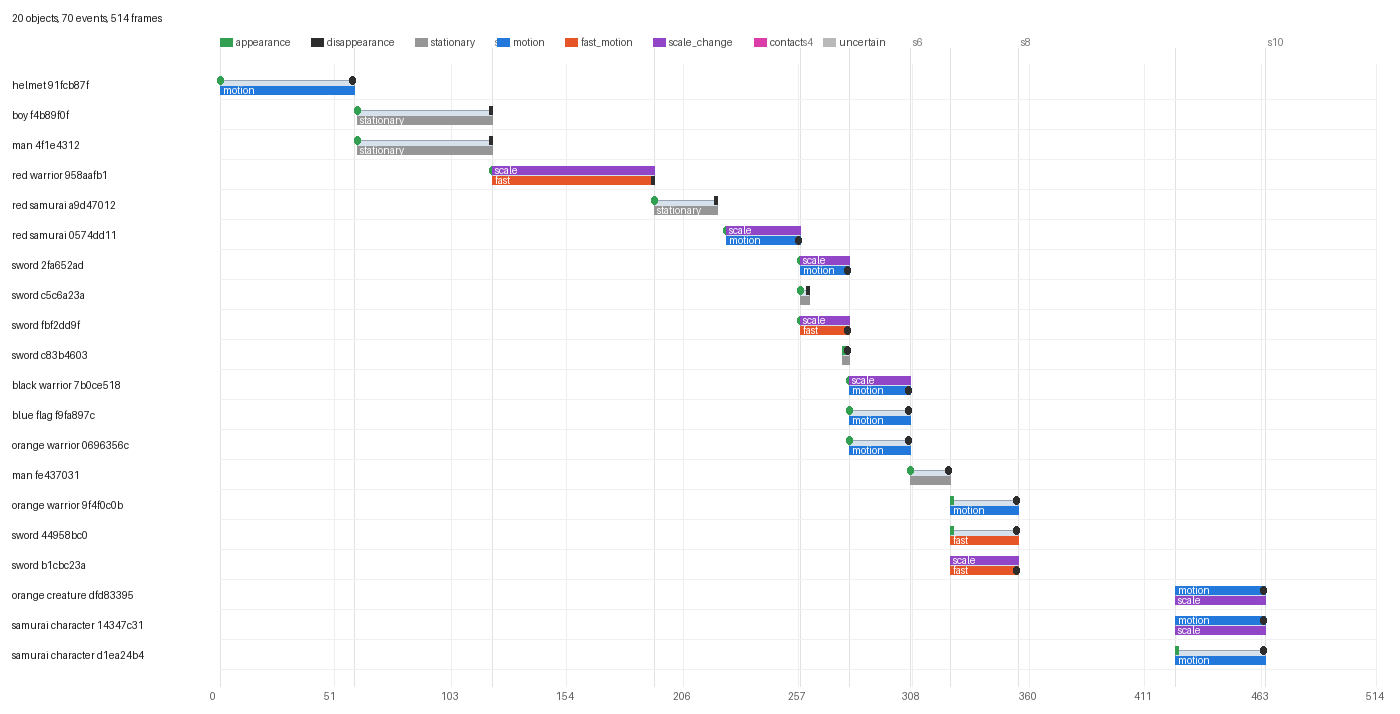

PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/event_track_extraction/visual_timeline.png')

In [6]:
visual_timeline = render_visual_timeline(video_asset)
visual_timeline_path = OUTPUT_DIR / "visual_timeline.png"
visual_timeline.save(visual_timeline_path)
display_image(visual_timeline)
visual_timeline_path

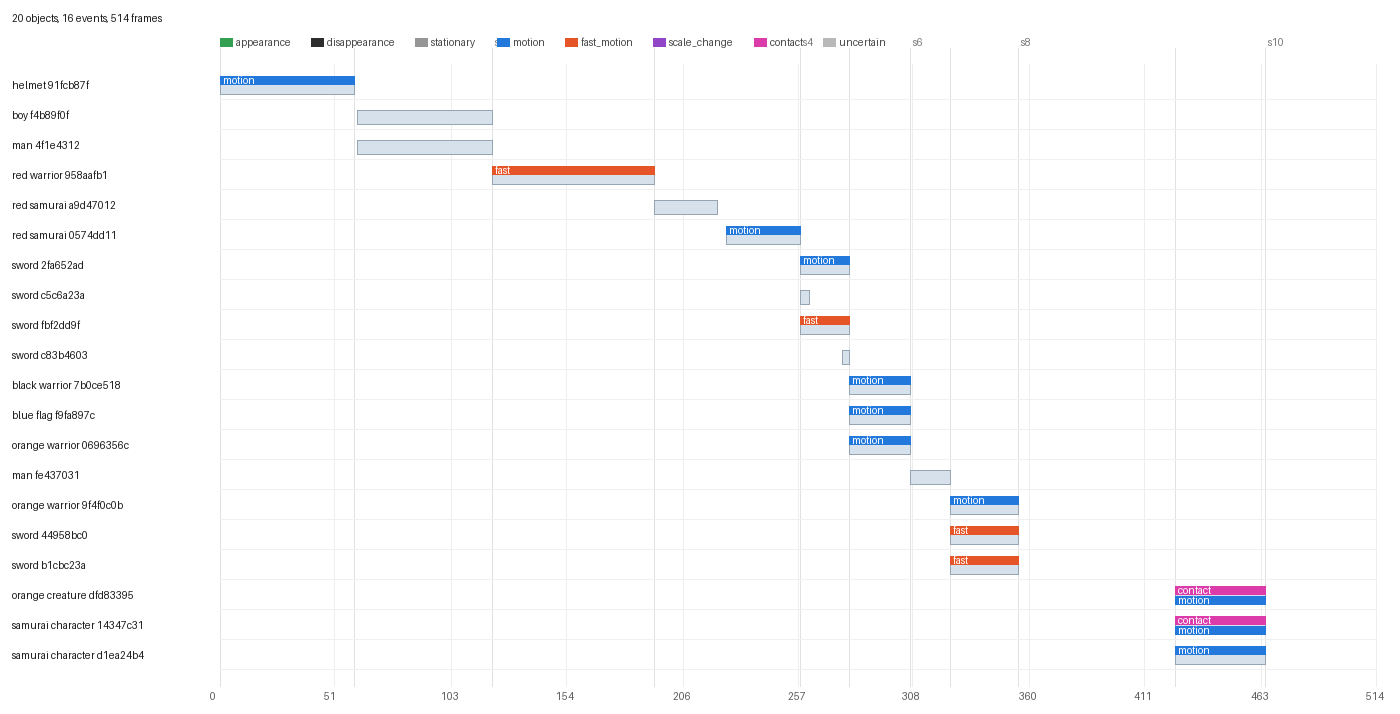

PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/event_track_extraction/visual_timeline_motion_contact.png')

In [7]:
filtered_visual_timeline = render_visual_timeline(
    video_asset,
    event_types={"motion", "fast_motion", "contact"},
)
filtered_visual_timeline_path = OUTPUT_DIR / "visual_timeline_motion_contact.png"
filtered_visual_timeline.save(filtered_visual_timeline_path)
display_image(filtered_visual_timeline)
filtered_visual_timeline_path

## Resolve Source Video

Rendering uses the prepared source video stored on the asset. If the path is not available, the notebook falls back to `test.mp4` when present.

In [8]:
video_path = Path(video_asset.source_path)
if not video_path.exists():
    fallback_path = PROJECT_ROOT / "test.mp4"
    if fallback_path.exists():
        video_path = fallback_path

if not video_path.exists():
    raise FileNotFoundError(f"Could not find source video: {video_asset.source_path}")

video_path

PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/agent_seed_tracking/work/13.prepared.mp4')

## Motion Track Summary Image

This renders all selected motion event tracks on one background frame. Masks are sparse start/mid/end overlays to avoid hiding the image.

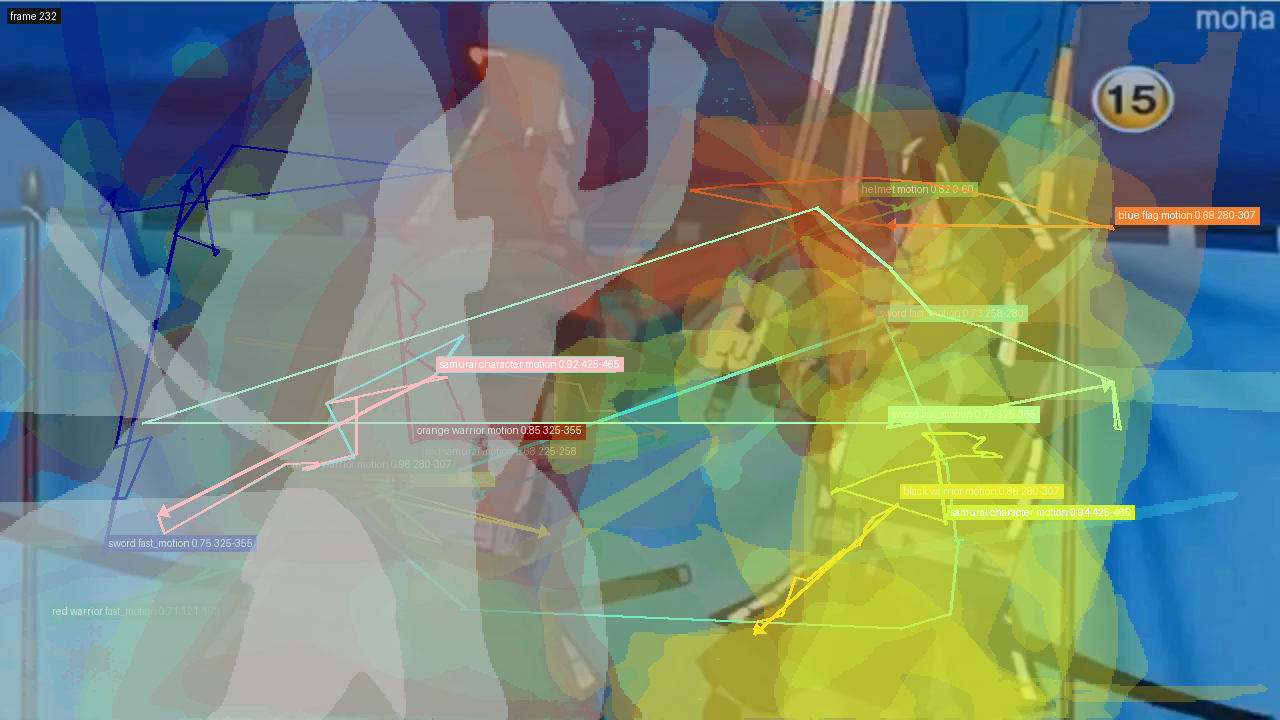

PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/event_track_extraction/motion_tracks.png')

In [9]:
selected_event_rows = [
    row for row in event_rows if row["event_type"] in SELECTED_EVENT_TYPES
]

if selected_event_rows:
    try:
        motion_image_path = render_motion_tracks_image(
            video_path,
            video_asset,
            OUTPUT_DIR / "motion_tracks.png",
            event_types=SELECTED_EVENT_TYPES,
        )
        display_image(motion_image_path)
    except ValueError as exc:
        motion_image_path = None
        print(f"Skipped motion image render: {exc}")
else:
    motion_image_path = None
    print(
        {
            "skipped": "No events match SELECTED_EVENT_TYPES",
            "selected_event_types": sorted(SELECTED_EVENT_TYPES),
            "available_event_counts": dict(sorted(event_counts.items())),
        }
    )

motion_image_path


## Motion Track Video

The video render is limited to one scene by default. If `SELECTED_SCENE_INDEXES` is unset, the first scene containing a selected motion event is used.

In [10]:
motion_scene_indexes = sorted(
    {
        row["scene_index"]
        for row in event_rows
        if row["event_type"] in SELECTED_EVENT_TYPES and row["scene_index"] is not None
    }
)

if SELECTED_SCENE_INDEXES is not None:
    candidate_scene_indexes = SELECTED_SCENE_INDEXES
else:
    candidate_scene_indexes = motion_scene_indexes[:1]

if candidate_scene_indexes:
    video_scene_index = candidate_scene_indexes[0]
    video_scene = video_asset.initial_scenes[video_scene_index]
    video_scene_summary = {
        "video_scene_index": video_scene_index,
        "start_frame_index": video_scene.start_frame_index,
        "end_frame_index": video_scene.end_frame_index,
    }
else:
    video_scene_index = None
    video_scene = None
    video_scene_summary = {
        "skipped": "No scenes contain selected motion events",
        "selected_event_types": sorted(SELECTED_EVENT_TYPES),
        "available_event_counts": dict(sorted(event_counts.items())),
    }

video_scene_summary


{'video_scene_index': 0, 'start_frame_index': 0, 'end_frame_index': 60}

In [11]:
if RENDER_VIDEO and video_scene is not None:
    try:
        motion_video_path = render_motion_tracks_video(
            video_path,
            video_asset,
            OUTPUT_DIR / f"motion_tracks_scene_{video_scene_index:03d}.mp4",
            event_types=SELECTED_EVENT_TYPES,
            start_frame_index=video_scene.start_frame_index,
            end_frame_index=video_scene.end_frame_index,
        )
        display_video(motion_video_path)
    except ValueError as exc:
        motion_video_path = None
        print(f"Skipped motion video render: {exc}")
elif RENDER_VIDEO:
    motion_video_path = None
    print("Skipped motion video render: no selected motion scene.")
else:
    motion_video_path = None

motion_video_path


PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/event_track_extraction/motion_tracks_scene_000.mp4')

## Save Event Artifact

This writes a new asset with `visual_identity_layer.visual_events`; it does not overwrite the tracking notebook output.

In [12]:
if SAVE_EVENT_ASSET:
    event_asset_path = OUTPUT_DIR / "video_asset.with_events.json"
    event_asset_path.write_text(video_asset.model_dump_json(indent=2, exclude_computed_fields=True), encoding="utf-8")
else:
    event_asset_path = None

event_asset_path

PosixPath('/home/gwpark0741/NC/v2a_inspect/demo/outputs/event_track_extraction/video_asset.with_events.json')